In [56]:
import torch
import torch.nn as nn
import numpy as np
import glob

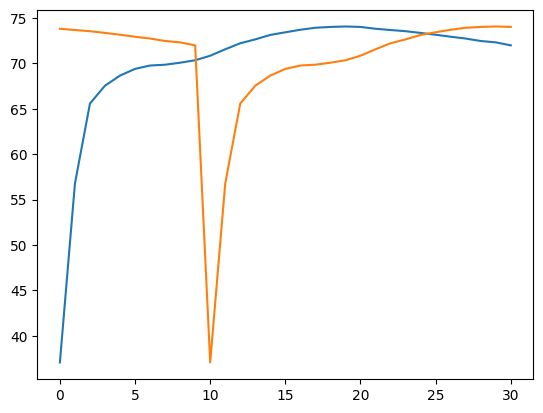

In [76]:
metal = np.load("materials_numpy/metal.npy")
import matplotlib.pyplot as plt
plt.plot(metal)

metal2 = torch.roll(torch.from_numpy(metal), 10)

plt.plot(metal2)

In [77]:
metal = torch.from_numpy(metal).float()
metal2 = metal2.float()
#repeat
metal = metal.repeat(2,32,32,1)
metal2 = metal2.repeat(2,32,32,1)


In [78]:
category2code = {"asphalt": 0, "ceramic": 1, "concrete": 2, "fabric": 3, "foliage": 4,
                            "food": 5, "glass": 6, "metal": 7, "paper": 8, "plaster": 9, "plastic": 10,
                            "rubber": 11, "soil": 12, "stone": 13, "water": 14, "wood": 15}

class SADPixelwise(nn.Module):
    def __init__(self,device):
        super(SADPixelwise, self).__init__()
        materials = glob.glob('materials/*.npy')
        materials = [torch.from_numpy(np.load(m)).float().to(device) for m in materials]
        self.code2material = {v: k for k, v in zip(materials, category2code.values())}
        self.num_bands = 31

    def forward(self, input, target):
        """
        Spectral Angle Distance Objective modified for hyperspectral images.
        Operates on each pixel and then sums the SAD across all pixels.

        Params:
            input -> Output of the network (batch_size, height, width, 31)
            target -> Hyperspectral image (batch_size, height, width, 31)

        Returns:
            total_sad: Sum of SAD across all pixels
        """

        try:
            normalize_r = torch.norm(input, p=2, dim=3, keepdim=True)
            normalize_g = torch.norm(target, p=2, dim=3, keepdim=True)
            numerator = torch.sum(torch.mul(input, target), dim=3, keepdim=True)

            elemnt = numerator / (normalize_r * normalize_g)

            sad = torch.acos(elemnt)


        except ValueError:
            return 0.0
        
        return torch.sum(sad)
    

sad = SADPixelwise('cpu')
print(sad(metal, metal2 ))

tensor(301.7060)
